## 1. Download the MNIST dataset and visualize some samples.

Image shape: torch.Size([1, 28, 28])
Label: 5


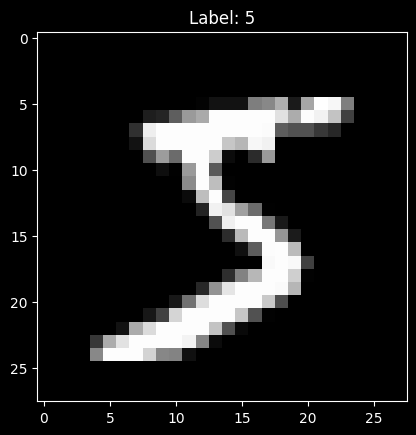

In [12]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

image, label = train_data[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

## 2. Batch the MNIST dataset

In [13]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


## 3. Model definition

In [14]:
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()

        # Flatten the input images
        self.flatten = nn.Flatten()

        # Fully connected layers
        # Linear layer that takes the flattened image (28*28) and outputs 128 features

        # TL;DR Turn pixels into vectors
        self.fc1 = nn.Linear(28 * 28, 128)

        # ReLU activation function
        self.relu = nn.ReLU()

        # Output layer
        # TL;DR Classify the image into 10 classes
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN()
print(model)

output = model(image.unsqueeze(0))

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Setup for training

In [15]:
loss_fn = nn.CrossEntropyLoss() # How wrong is the model?
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # Learning rate and optimization algorithm

## 5. Train the model

In [16]:
# Guess → measure wrongness → figure out nudges → apply nudges → repeat

for epoch in range(5):
    total_loss = 0

    for images, labels in train_loader:
        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = loss_fn(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()

        # Calculate gradients
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, avg loss: {total_loss / len(train_loader):.4f}")

Epoch 1, avg loss: 1.2486
Epoch 2, avg loss: 0.4967
Epoch 3, avg loss: 0.3954
Epoch 4, avg loss: 0.3543
Epoch 5, avg loss: 0.3293


## 6. Full run

In [17]:
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

correct = 0
total = 0

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        guesses = torch.argmax(outputs, dim=1)

        correct += (guesses == labels).sum().item()
        total += labels.size(0)

print(f"Accuracy: {(correct / total) * 100:.2f}%")

Accuracy: 91.45%
